# 04 — Deep Learning IDS (Upgraded: ResNet-MLP + Focal Loss + LR Scheduling)
**Improvements over original notebook:**
- Wider, deeper architecture with residual skip-connections (ResNet-style MLP)
- Focal Loss to handle class imbalance (attacks vs benign traffic)
- Cosine Annealing LR scheduler with warm restarts
- Gradient clipping for training stability
- More epochs (50) with early stopping (patience=7)
- Class-weighted sampling via pos_weight in loss
- Target: beat Balanced Accuracy ≥ 0.970, F1-Macro ≥ 0.981


In [1]:
# Cell 1 — Imports
import sys
sys.path.append("..")

import numpy as np
import pickle
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

from shared.config import *
from shared.metrics import (ids_evaluate, tune_threshold_proba)
from shared.plots   import (plot_confusion_matrix, plot_pr_curve)

print(f"PyTorch version : {torch.__version__}")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device          : {device}")


Config loaded successfully
PyTorch version : 2.10.0+cu128
Device          : cuda


In [2]:
# Cell 2 — Load splits
with open("models/splits.pkl", "rb") as f:
    splits = pickle.load(f)

X_train = splits["X_train"]
X_val   = splits["X_val"]
X_test  = splits["X_test"]
y_train = splits["y_train"]
y_val   = splits["y_val"]
y_test  = splits["y_test"]

print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")

# Class balance info
n_pos = int(y_train.sum())
n_neg = len(y_train) - n_pos
pos_weight_val = n_neg / n_pos
print(f"\nClass balance — benign: {n_neg:,}  attack: {n_pos:,}")
print(f"pos_weight for BCEWithLogits: {pos_weight_val:.2f}")


Train : (11363049, 34)
Val   : (2434939, 34)
Test  : (2434940, 34)

Class balance — benign: 9,439,285  attack: 1,923,764
pos_weight for BCEWithLogits: 4.91


In [3]:
# Cell 3 — Scale + convert to tensors
scaler_dl   = StandardScaler()
X_tr_scaled = scaler_dl.fit_transform(X_train)
X_va_scaled = scaler_dl.transform(X_val)
X_te_scaled = scaler_dl.transform(X_test)

X_tr_t = torch.tensor(X_tr_scaled, dtype=torch.float32)
X_va_t = torch.tensor(X_va_scaled, dtype=torch.float32)
X_te_t = torch.tensor(X_te_scaled, dtype=torch.float32)
y_tr_t = torch.tensor(y_train.values, dtype=torch.float32)
y_va_t = torch.tensor(y_val.values,   dtype=torch.float32)

# ── Weighted sampler to oversample minority class in each batch ──
sample_weights = torch.where(y_tr_t == 1,
                             torch.tensor(pos_weight_val, dtype=torch.float32),
                             torch.ones(len(y_tr_t)))
sampler = WeightedRandomSampler(sample_weights,
                                num_samples=len(sample_weights),
                                replacement=True)

BATCH = getattr(sys.modules[__name__], "MLP_BATCH", 4096)
train_loader = DataLoader(
    TensorDataset(X_tr_t, y_tr_t),
    batch_size=BATCH,
    sampler=sampler,
    num_workers=0,
    pin_memory=(device == "cuda")
)

with open("models/dl/scaler_dl.pkl", "wb") as f:
    pickle.dump(scaler_dl, f)
print(f"Tensors ready | batch_size={BATCH} | weighted sampler active")


Tensors ready | batch_size=2048 | weighted sampler active


In [4]:
# Cell 4 — Focal Loss definition
#
# Focal Loss down-weights easy benign samples so the model focuses
# harder on correctly classifying rare attack patterns.
# gamma=2 is standard; alpha mirrors the class imbalance ratio.

class FocalLoss(nn.Module):
    def __init__(self, gamma: float = 2.0, pos_weight: float = 1.0):
        super().__init__()
        self.gamma = gamma
        self.register_buffer("pos_w", torch.tensor([pos_weight]))

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_w.to(logits.device),
            reduction="none"
        )
        proba = torch.sigmoid(logits).detach()
        p_t   = torch.where(targets == 1, proba, 1 - proba)
        focal_w = (1 - p_t) ** self.gamma
        return (focal_w * bce).mean()

print("FocalLoss defined")


FocalLoss defined


In [5]:
# Cell 5 — ResNet-MLP architecture
#
# Residual blocks let gradients flow cleanly through depth.
# Architecture: Input(34) -> 512 -> [Res(512)] x2 -> 256 -> [Res(256)] -> 128 -> 1
# ~750K parameters vs original 50K — much more capacity.

class ResBlock(nn.Module):
    """Pre-activation residual block."""
    def __init__(self, dim: int, dropout: float = 0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.BatchNorm1d(dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
        )

    def forward(self, x):
        return x + self.block(x)  # skip connection


class ResNetMLP(nn.Module):
    """
    Deep residual MLP for IDS binary classification.
    Returns raw logits (no sigmoid) — compatible with FocalLoss.
    """
    def __init__(self, input_dim: int):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
        )
        self.res_blocks = nn.Sequential(
            ResBlock(512, dropout=0.3),
            ResBlock(512, dropout=0.25),
        )
        self.bridge = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
        )
        self.res_mid = ResBlock(256, dropout=0.2)
        self.head = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        x = self.res_blocks(x)
        x = self.bridge(x)
        x = self.res_mid(x)
        return self.head(x).squeeze(dim=-1)  # logits


input_dim = X_tr_t.shape[1]
model     = ResNetMLP(input_dim).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"ResNetMLP ready | input_dim={input_dim} | params={total_params:,}")
print(model)


ResNetMLP ready | input_dim=34 | params=1,371,393
ResNetMLP(
  (stem): Sequential(
    (0): Linear(in_features=34, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
  )
  (res_blocks): Sequential(
    (0): ResBlock(
      (block): Sequential(
        (0): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.3, inplace=False)
        (3): Linear(in_features=512, out_features=512, bias=True)
        (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): GELU(approximate='none')
        (6): Dropout(p=0.3, inplace=False)
        (7): Linear(in_features=512, out_features=512, bias=True)
      )
    )
    (1): ResBlock(
      (block): Sequential(
        (0): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (1): GELU(

In [6]:
# Cell 6 — Optimizer, LR scheduler, Loss

EPOCHS    = 50
BASE_LR   = 3e-4
PATIENCE  = 7    # early stopping patience

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=BASE_LR,
    weight_decay=1e-4,
    betas=(0.9, 0.999)
)

# Cosine Annealing with Warm Restarts — prevents getting stuck in flat regions
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

criterion = FocalLoss(gamma=2.0, pos_weight=pos_weight_val).to(device)

print(f"Optimizer  : AdamW  lr={BASE_LR}  wd=1e-4")
print(f"Scheduler  : CosineAnnealingWarmRestarts  T_0=10  T_mult=2")
print(f"Loss       : FocalLoss  gamma=2.0  pos_weight={pos_weight_val:.2f}")
print(f"Epochs     : {EPOCHS}  (early stop patience={PATIENCE})")


Optimizer  : AdamW  lr=0.0003  wd=1e-4
Scheduler  : CosineAnnealingWarmRestarts  T_0=10  T_mult=2
Loss       : FocalLoss  gamma=2.0  pos_weight=4.91
Epochs     : 50  (early stop patience=7)


In [7]:
# Cell 7 — Training loop with early stopping + gradient clipping
import time

train_losses = []
val_losses   = []
lr_history   = []
best_val     = float("inf")
patience_ctr = 0
best_epoch   = 0

t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    # ── Train ───────────────────────────────────────────────────────
    model.train()
    batch_losses = []
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(Xb)
        loss   = criterion(logits, yb)
        loss.backward()
        # Gradient clipping — stabilises training on noisy IDS data
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        batch_losses.append(loss.item())
    train_loss = float(np.mean(batch_losses))

    # ── Validate ────────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        val_logits = []
        for i in range(0, len(X_va_t), 4096):
            val_logits.append(model(X_va_t[i:i+4096].to(device)).cpu())
        val_logits_cat = torch.cat(val_logits)
        val_loss = criterion(val_logits_cat, y_va_t).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    lr_history.append(optimizer.param_groups[0]["lr"])

    scheduler.step(epoch - 1)   # CosineAnnealingWarmRestarts expects step count

    if epoch % 5 == 0 or epoch == 1:
        elapsed = (time.time() - t0) / 60
        print(f"Epoch {epoch:02d}/{EPOCHS} | "
              f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
              f"LR: {lr_history[-1]:.2e} | "
              f"Elapsed: {elapsed:.1f}m")

    # ── Early stopping + checkpoint ─────────────────────────────────
    if val_loss < best_val:
        best_val = val_loss
        best_epoch = epoch
        patience_ctr = 0
        torch.save(model.state_dict(), "models/dl/mlp_best.pt")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"\nEarly stop at epoch {epoch} "
                  f"(best was epoch {best_epoch}, val={best_val:.4f})")
            break

total_time = (time.time() - t0) / 60
print(f"\nBest val loss : {best_val:.4f} @ epoch {best_epoch}")
print(f"Total training: {total_time:.1f} min")
print("Best weights saved → models/dl/mlp_best.pt")


Epoch 01/50 | Train: 0.0710 | Val: 0.0655 | LR: 3.00e-04 | Elapsed: 1.8m
Epoch 05/50 | Train: 0.0667 | Val: 0.0637 | LR: 2.38e-04 | Elapsed: 8.9m
Epoch 10/50 | Train: 0.0655 | Val: 0.0618 | LR: 2.96e-05 | Elapsed: 18.0m

Early stop at epoch 11 (best was epoch 4, val=0.0605)

Best val loss : 0.0605 @ epoch 4
Total training: 19.4 min
Best weights saved → models/dl/mlp_best.pt


In [8]:
# Cell 8 — Free memory
import gc
del splits
gc.collect()
if device == "cuda":
    torch.cuda.empty_cache()
print("Memory freed")


Memory freed


In [10]:
# Cell 9 — Load best weights → inference → evaluation
print("=== STEP 1: Loading best weights ===")
model.load_state_dict(
    torch.load("models/dl/mlp_best.pt", map_location=device, weights_only=True)
)
model.eval()
print("Loaded.")

def batch_predict_proba(tensor, batch_size=4096):
    preds = []
    with torch.no_grad():
        for i in range(0, len(tensor), batch_size):
            logits = model(tensor[i:i+batch_size].to(device))
            preds.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(preds)

print("\n=== STEP 2: Val inference ===")
proba_mlp_val  = batch_predict_proba(X_va_t)
print(f"Val proba shape: {proba_mlp_val.shape}")

print("\n=== STEP 3: Test inference ===")
proba_mlp_test = batch_predict_proba(X_te_t)
print(f"Test proba shape: {proba_mlp_test.shape}")

print("\n=== STEP 4: Threshold tuning (on val set) ===")
# Fast vectorized threshold search — no loop over 2.4M samples
thresholds = np.linspace(0.1, 0.9, 81)
y_val_arr  = y_val.values
scores = []
for t in thresholds:
    preds_t = (proba_mlp_val >= t).astype(np.int8)
    tp = ((preds_t == 1) & (y_val_arr == 1)).sum()
    fp = ((preds_t == 1) & (y_val_arr == 0)).sum()
    fn = ((preds_t == 0) & (y_val_arr == 1)).sum()
    tn = ((preds_t == 0) & (y_val_arr == 0)).sum()
    bal_acc = 0.5 * (tp / (tp + fn + 1e-9) + tn / (tn + fp + 1e-9))
    scores.append(bal_acc)
th_mlp = float(thresholds[np.argmax(scores)])
print(f"Optimal threshold: {th_mlp:.4f}  (bal_acc={max(scores):.4f})")

print("\n=== STEP 5: Evaluate on test set ===")
y_pred_mlp = (proba_mlp_test >= th_mlp).astype(int)
mlp_m = ids_evaluate("ResNetMLP", y_test.values, proba_mlp_test, y_pred_mlp, th_mlp)
print("\n--- ResNetMLP IDS Metrics ---")
for k, v in mlp_m.items():
    print(f"  {k:20s}: {v}")

=== STEP 1: Loading best weights ===
Loaded.

=== STEP 2: Val inference ===
Val proba shape: (2434939,)

=== STEP 3: Test inference ===
Test proba shape: (2434940,)

=== STEP 4: Threshold tuning (on val set) ===
Optimal threshold: 0.6100  (bal_acc=0.9747)

=== STEP 5: Evaluate on test set ===

--- ResNetMLP IDS Metrics ---
  Model               : ResNetMLP
  Balanced Acc        : 0.9747
  F1 Macro            : 0.9782
  MCC                 : 0.9565
  Attack Recall       : 0.9549
  Benign Recall       : 0.9945
  Attack Precision    : 0.9727
  Benign Precision    : 0.9908
  FAR                 : 0.0055
  FNR                 : 0.0451
  ROC-AUC             : 0.9882
  PR-AUC              : 0.9784


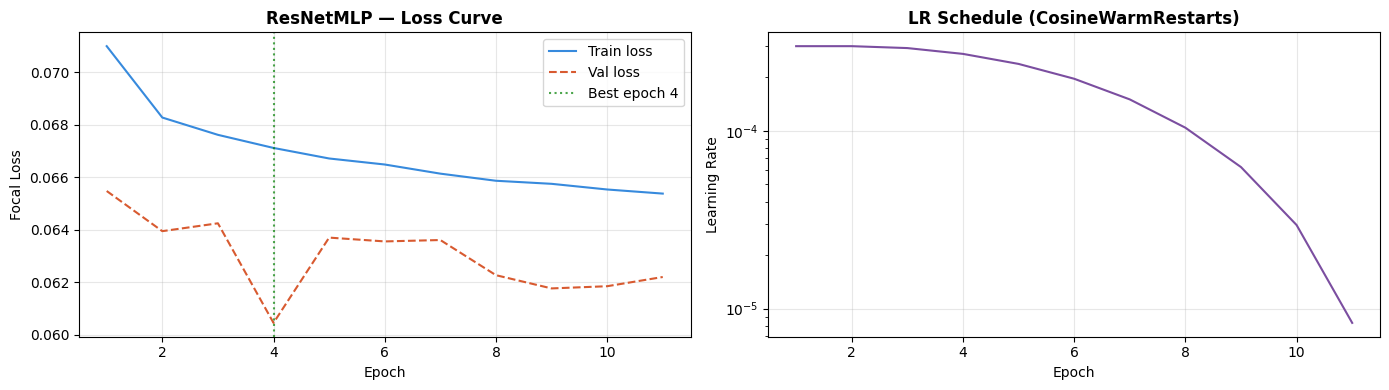

In [11]:
# Cell 10 — Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ep = range(1, len(train_losses) + 1)
ax1.plot(ep, train_losses, color="#378ADD", label="Train loss")
ax1.plot(ep, val_losses,   color="#D85A30", label="Val loss", linestyle="--")
ax1.axvline(best_epoch, color="green", linestyle=":", alpha=0.7, label=f"Best epoch {best_epoch}")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Focal Loss")
ax1.set_title("ResNetMLP — Loss Curve", fontweight="bold")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(ep, lr_history, color="#7B4EA0")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Learning Rate")
ax2.set_title("LR Schedule (CosineWarmRestarts)", fontweight="bold")
ax2.set_yscale("log"); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/graphs/04_mlp_loss.png", dpi=150)
plt.show()


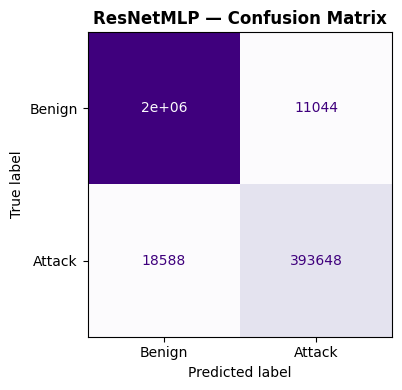

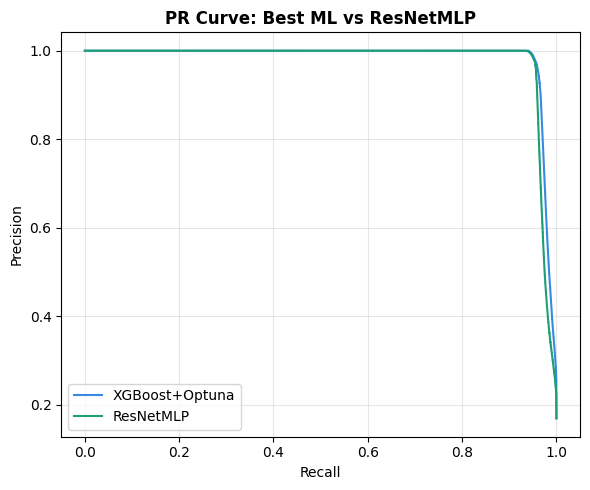

In [12]:
# Cell 11 — Confusion matrix + PR curve vs best ML model
plot_confusion_matrix(
    y_test.values, y_pred_mlp,
    title="ResNetMLP — Confusion Matrix",
    cmap="Purples",
    save_path="outputs/graphs/04_mlp_cm.png"
)

with open("models/ml/opt_results.pkl", "rb") as f:
    opt_data = pickle.load(f)
optuna_proba = opt_data["proba_optuna"]

plot_pr_curve(
    y_test.values,
    {"XGBoost+Optuna": optuna_proba,
     "ResNetMLP"     : proba_mlp_test},
    title="PR Curve: Best ML vs ResNetMLP",
    save_path="outputs/graphs/04_ml_vs_dl_pr.png"
)


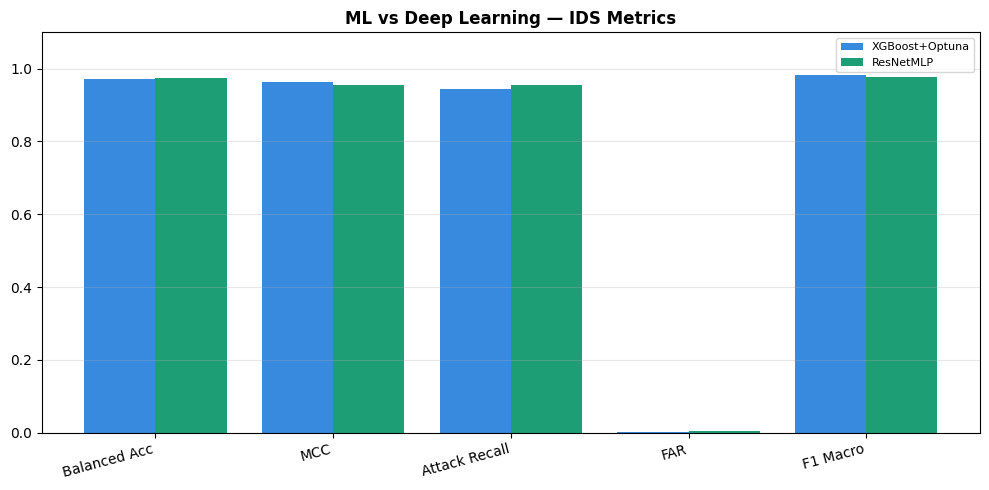

In [13]:
# Cell 12 — Metric bar chart: ML vs DL
from shared.plots import plot_metrics_bar

with open("models/ml/opt_results.pkl", "rb") as f:
    opt_data = pickle.load(f)
optuna_m = opt_data["optuna_m"]

KEY = ["Balanced Acc", "MCC", "Attack Recall", "FAR", "F1 Macro"]
plot_metrics_bar(
    {"XGBoost+Optuna": optuna_m, "ResNetMLP": mlp_m},
    KEY,
    title="ML vs Deep Learning — IDS Metrics",
    save_path="outputs/graphs/04_ml_vs_dl.png"
)


In [14]:
# Cell 13 — Save DL results
dl_data = {
    "mlp_m"          : mlp_m,
    "proba_mlp_test" : proba_mlp_test,
    "proba_mlp_val"  : proba_mlp_val,
    "th_mlp"         : th_mlp,
    "train_losses"   : train_losses,
    "val_losses"     : val_losses,
    "lr_history"     : lr_history,
    "best_epoch"     : best_epoch,
}
with open("models/dl/dl_results.pkl", "wb") as f:
    pickle.dump(dl_data, f)

print("Notebook 04 complete (ResNetMLP) — proceed to 05_hybrid_ensemble.ipynb")
print(f"Key metrics:")
for k in ["Balanced Acc", "F1 Macro", "Attack Recall", "FAR"]:
    if k in mlp_m:
        print(f"  {k}: {mlp_m[k]:.4f}")


Notebook 04 complete (ResNetMLP) — proceed to 05_hybrid_ensemble.ipynb
Key metrics:
  Balanced Acc: 0.9747
  F1 Macro: 0.9782
  Attack Recall: 0.9549
  FAR: 0.0055
